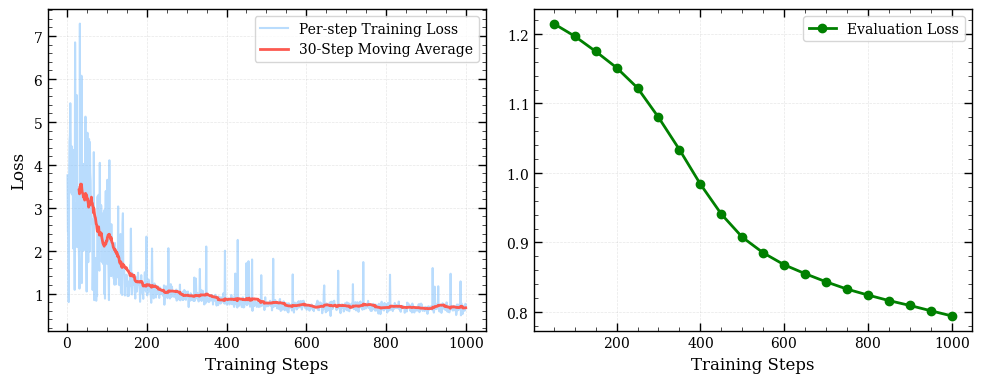

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import json

plt.style.use('../notebooks/mystyle.mplstyle')
# Load the data from the JSON file
with open('../results/lora/lora_r4_lr1e-05_ctx512/lora_r4_lr1e-05_ctx512_results.json', 'r') as f:
    data = json.load(f)

# Create a figure with two subplots arranged horizontally
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))  # Changed to 1 row, 2 columns

# Plot the training loss
steps = np.arange(1, len(data['train_losses']) + 1)
ax1.plot(steps, data['train_losses'], alpha=0.5, label='Per-step Training Loss')

# Calculate and plot a moving average for clarity
window_size = 30
if len(data['train_losses']) > window_size:
    moving_avg = np.convolve(data['train_losses'], np.ones(window_size)/window_size, mode='valid')
    ax1.plot(np.arange(window_size, len(data['train_losses']) + 1), moving_avg, linewidth=2, label=f'{window_size}-Step Moving Average')

#ax1.set_title(f'Training Loss Over Time\n(LR={data["learning_rate"]}, LoRA rank={data["lora_rank"]})')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Training Steps')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add the evaluation loss on the second subplot
ax2.plot(data['eval_steps'], data['eval_losses'], 'g-o', linewidth=2, label='Evaluation Loss')
# ax2.set_title('Evaluation Loss')
# ax2.set_ylabel('Loss')
ax2.set_xlabel('Training Steps')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/notebook_figs/training_0.pdf')
plt.show()

In [7]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator


# Path to the results directory
results_dir = '../results/hyperparam_search'

# Function to extract parameters from filename
def extract_params(filename):
    parts = filename.split('_')
    rank = int(parts[1][1:])
    lr = float(parts[2][2:])
    ctx = int(parts[3][3:])
    return rank, lr, ctx

# Load all JSON files
results = []
for filename in os.listdir(results_dir):
    if filename.endswith('_results.json'):
        with open(os.path.join(results_dir, filename), 'r') as f:
            data = json.load(f)
            # Extract parameters from the filename
            rank, lr, ctx = extract_params(filename.split('_results.json')[0])
            
            # Add configuration to the data
            data['rank'] = rank
            data['lr'] = lr
            data['ctx'] = ctx
            
            results.append(data)

# Create a DataFrame for eval losses
eval_dfs = []
for result in results:
    df = pd.DataFrame({
        'step': result['eval_steps'],
        'eval_loss': result['eval_losses'],
        'rank': result['rank'],
        'lr': result['lr'],
        'ctx': result['ctx'],
        'config': f"r={result['rank']}, lr={result['lr']}, ctx={result['ctx']}"
    })
    eval_dfs.append(df)

eval_df = pd.concat(eval_dfs)

# Create a DataFrame for train losses (sampling for readability)
train_dfs = []
for result in results:
    # Sample training losses for cleaner plotting
    train_losses = result['train_losses']
    sample_rate = max(1, len(train_losses) // 100)  # Keep ~100 points
    steps = list(range(1, len(train_losses) + 1))
    
    df = pd.DataFrame({
        'step': steps[::sample_rate],
        'train_loss': train_losses[::sample_rate],
        'rank': result['rank'],
        'lr': result['lr'],
        'ctx': result['ctx'],
        'config': f"r={result['rank']}, lr={result['lr']}, ctx={result['ctx']}"
    })
    train_dfs.append(df)

train_df = pd.concat(train_dfs)

# Create a summary DataFrame
summary_df = pd.DataFrame([
    {
        'rank': r['rank'], 
        'lr': r['lr'], 
        'ctx': r['ctx'],
        'final_train_loss': r['train_losses'][-1],
        'final_eval_loss': r['final_eval_loss'],
        'best_eval_loss': r['best_eval_loss']
    } for r in results
])


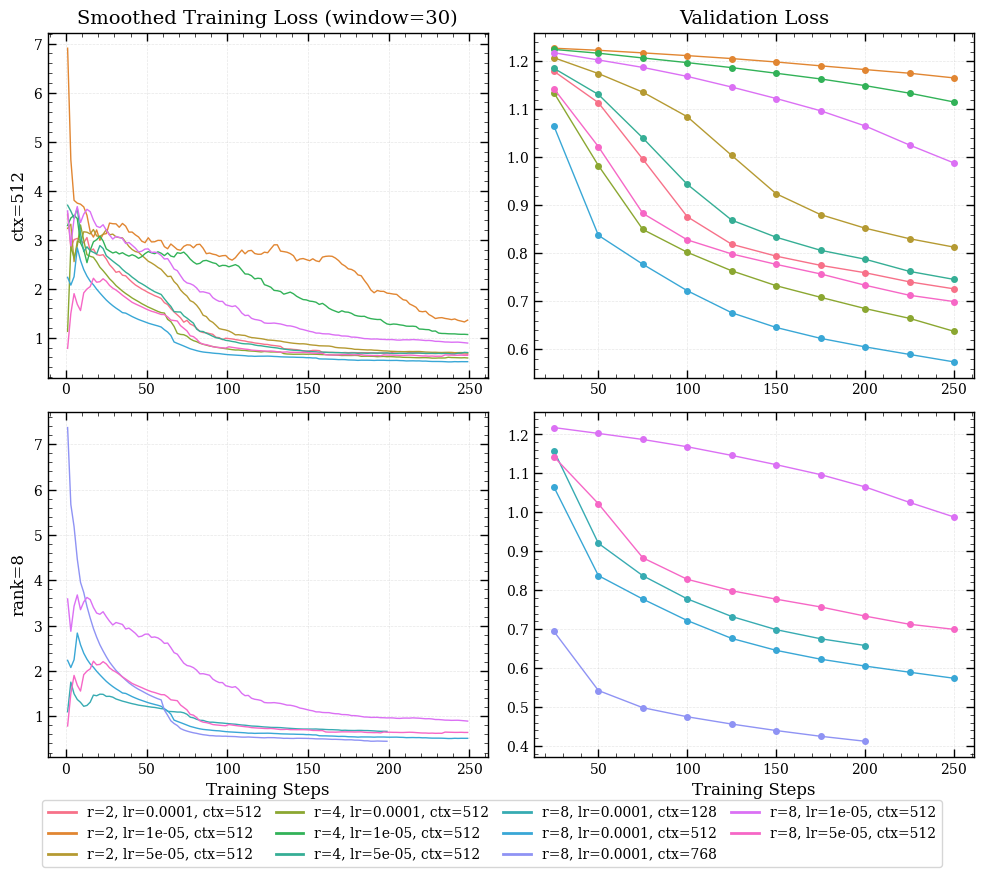

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import numpy as np

# Get all unique configurations
all_configs = sorted(set(train_df['config'].unique()) | set(eval_df['config'].unique()))

# Create a color mapping with distinct colors
n_colors = len(all_configs)
palette = sns.color_palette("husl", n_colors)  # husl space gives perceptually distinct colors
config_colors = dict(zip(all_configs, palette))

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

# 1. Smoothed training losses for ctx=512 (top-left)
ctx_filter = 512
subset_df = train_df[train_df['ctx'] == ctx_filter]
ax = axes[0, 0]

for config in sorted(subset_df['config'].unique()):
    subset = subset_df[subset_df['config'] == config]
    # Simple moving average for smoothing
    window_size = 30
    subset_smoothed = subset.copy()
    subset_smoothed['train_loss'] = subset['train_loss'].rolling(window=window_size, min_periods=1).mean()
    ax.plot(subset_smoothed['step'], subset_smoothed['train_loss'], 
            color=config_colors[config], linewidth=1)

ax.set_title(f'Smoothed Training Loss (window={window_size})')
ax.set_ylabel(f'ctx={ctx_filter}')
ax.grid(True, alpha=0.3)

# 2. Validation losses for ctx=512 (top-right)
subset_df = eval_df[eval_df['ctx'] == ctx_filter]
ax = axes[0, 1]

for config in sorted(subset_df['config'].unique()):
    subset = subset_df[subset_df['config'] == config]
    ax.plot(subset['step'], subset['eval_loss'], marker='o', markersize=4,
            color=config_colors[config], linewidth=1)


ax.set_title(f'Validation Loss')
ax.grid(True, alpha=0.3)

# 3. Smoothed training losses for r=8 (bottom-left)
rank_filter = 8
subset_df = train_df[train_df['rank'] == rank_filter]
ax = axes[1, 0]

for config in sorted(subset_df['config'].unique()):
    subset = subset_df[subset_df['config'] == config]
    # Simple moving average for smoothing
    window_size = 30
    subset_smoothed = subset.copy()
    subset_smoothed['train_loss'] = subset['train_loss'].rolling(window=window_size, min_periods=1).mean()
    ax.plot(subset_smoothed['step'], subset_smoothed['train_loss'], 
            color=config_colors[config], linewidth=1)

ax.set_xlabel('Training Steps')
ax.set_ylabel(f'rank={rank_filter}')
ax.grid(True, alpha=0.3)

# 4. Validation losses for r=8 (bottom-right)
subset_df = eval_df[eval_df['rank'] == rank_filter]
ax = axes[1, 1]

for config in sorted(subset_df['config'].unique()):
    subset = subset_df[subset_df['config'] == config]
    ax.plot(subset['step'], subset['eval_loss'], marker='o', markersize=4,
            color=config_colors[config], linewidth=1)


ax.set_xlabel('Training Steps')
ax.grid(True, alpha=0.3)

# Create a consolidated legend outside the plots
# First gather all unique configs used in the plots
used_configs = (set(train_df[train_df['ctx'] == ctx_filter]['config']) | 
                set(eval_df[eval_df['ctx'] == ctx_filter]['config']) |
                set(train_df[train_df['rank'] == rank_filter]['config']) |
                set(eval_df[eval_df['rank'] == rank_filter]['config']))
used_configs = sorted(used_configs)

# Add a common legend below the plots
handles = [plt.Line2D([0], [0], color=config_colors[config], lw=2) for config in used_configs]
fig.legend(handles, used_configs, loc='lower center', bbox_to_anchor=(0.5, 0.02), 
           ncol=min(4, len(used_configs)), fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for the legend
plt.savefig('../results/notebook_figs/hyperparameter_comparison_subplots.pdf', dpi=300, bbox_inches='tight')
plt.show()

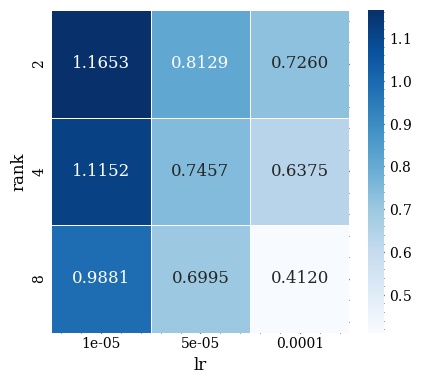

In [9]:
# 4. Heatmap of final validation losses
if len(summary_df) > 1:
    pivot_data = summary_df.pivot_table(
        index='rank', 
        columns='lr', 
        values='best_eval_loss',
        aggfunc='first'
    )
    
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(pivot_data, annot=True, cmap='Blues', linewidths=0.5, fmt='.4f')
    # plt.title('Best Validation Loss by Rank and Learning Rate')
    plt.tight_layout()
    plt.savefig('../results/notebook_figs/best_loss_heatmap.pdf')

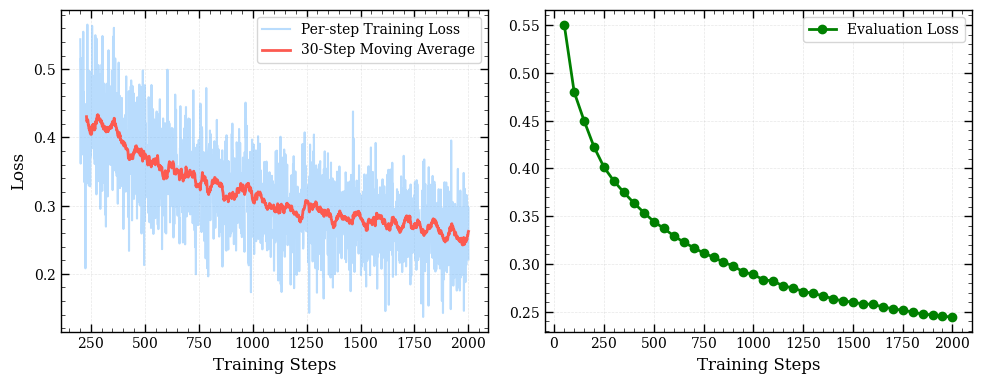

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import json

plt.style.use('../notebooks/mystyle.mplstyle')
# Load the data from the JSON file
with open('../results/final_model/lora_r8_lr0.0001_ctx768_results.json', 'r') as f:
    data = json.load(f)

# Create a figure with two subplots arranged horizontally
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))  # Changed to 1 row, 2 columns

# Plot the training loss
steps = np.arange(1, len(data['train_losses']) + 1)
ax1.plot(steps[200:], data['train_losses'][200:], alpha=0.5, label='Per-step Training Loss')

# Calculate and plot a moving average for clarity
window_size = 30
if len(data['train_losses']) > window_size:
    moving_avg = np.convolve(data['train_losses'], np.ones(window_size)/window_size, mode='valid')
    ax1.plot(np.arange(window_size, len(data['train_losses']) + 1)[200:], moving_avg[200:], linewidth=2, label=f'{window_size}-Step Moving Average')

#ax1.set_title(f'Training Loss Over Time\n(LR={data["learning_rate"]}, LoRA rank={data["lora_rank"]})')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Training Steps')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add the evaluation loss on the second subplot
ax2.plot(data['eval_steps'], data['eval_losses'], 'g-o', linewidth=2, label='Evaluation Loss')
# ax2.set_title('Evaluation Loss')
# ax2.set_ylabel('Loss')
ax2.set_xlabel('Training Steps')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/notebook_figs/training_final.pdf')
plt.show()

## FLOPS Summary

### Initial Experiment

  "learning_rate": 1e-05,
  "lora_rank": 4,
  "context_length": 512,
  "max_steps": 1000,
  "batch_size": 8,
  "total_flops": 13635749685248000,
  "total_training_flops": 13545446707200000,
  "total_inference_flops": 90302978048000,
  "training_flops_per_step": 13545446707200,
  "inference_flops_per_step": 4515148902400,


### Hyperparameter Search

Experiment,Learning Rate,LoRA Rank,Context Length,Steps,Total FLOPS (T),Best Loss
lora_r2_lr1e-05_ctx512,1e-05,2,512,250,3430.44240719872,1.1653479046127744
lora_r4_lr1e-05_ctx512,1e-05,4,512,250,3431.513165824,1.1152116510521148
lora_r8_lr1e-05_ctx512,1e-05,8,512,250,3433.65468307456,0.9881303347301188
lora_r2_lr5e-05_ctx512,5e-05,2,512,250,3430.44240719872,0.8129178892717273
lora_r4_lr5e-05_ctx512,5e-05,4,512,250,3431.513165824,0.7456611778713971
lora_r8_lr5e-05_ctx512,5e-05,8,512,250,3433.65468307456,0.6995000518143362
lora_r2_lr0.0001_ctx512,0.0001,2,512,250,3430.44240719872,0.7259904090834107
lora_r4_lr0.0001_ctx512,0.0001,4,512,250,3431.513165824,0.637537654523879
lora_r8_lr0.0001_ctx512,0.0001,8,512,250,3433.65468307456,0.5738634090674551
lora_r8_lr0.0001_ctx128,0.0001,8,128,200,665.202681479168,0.6580016255750382
lora_r8_lr0.0001_ctx768,0.0001,8,768,200,4206.498640232448,0.41204501688480377


### Final Training

  "learning_rate": 0.0001,
  "lora_rank": 8,
  "context_length": 768,
  "max_steps": 2000,
  "batch_size": 8,
  "total_flops": 41788243070730240,
  "total_training_flops": 41511499739136000,
  "total_inference_flops": 276743331594240,
  "training_flops_per_step": 20755749869568,
  "inference_flops_per_step": 6918583289856,


In [11]:
import pandas as pd
df = pd.read_csv('../results/hyperparam_search/flops_summary.csv')
search_sum = df['Total FLOPS (T)'].sum() * 1e12

percentage = (search_sum + 13635749685248000 + 41788243070730240) / 1e17
percentage

np.float64(0.9118252484598169)